In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(r'D:\Pycharm\Py_Projects\STAGATE_pyG-main-change\STAGATE_PyG')
import torch
torch.manual_seed(seed=2025)
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import STAGATE_pyG
import numpy as np
import pandas as pd
import libpysal
from esda.moran import Moran
os.environ['R_HOME'] = 'D:/anaconda3/R-4.0.3'
os.environ['R_USER'] = 'D:/anaconda3/envs/GraphST/Lib/site-packages/rpy2'

In [2]:
adata1 = sc.read_h5ad("E:/Spatial_data/muti_omics/miso_tutorial_data/updated_rna.h5ad")
adata2 = sc.read_h5ad("E:/Spatial_data/muti_omics/miso_tutorial_data/updated_protein.h5ad")
adata1.var_names_make_unique()
adata2.var_names_make_unique()

In [3]:
adata1

AnnData object with n_obs × n_vars = 4194 × 18085
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [4]:
# RNA
sc.pp.filter_genes(adata1, min_cells=10)
sc.pp.highly_variable_genes(adata1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata1, target_sum=1e4)
sc.pp.log1p(adata1)
sc.pp.scale(adata1)

In [5]:
# Protein
adata2 = STAGATE_pyG.clr_normalize_each_cell(adata2)
sc.pp.scale(adata2)

In [6]:
STAGATE_pyG.Cal_Spatial_Net(adata1, k_cutoff=6, model='KNN')
STAGATE_pyG.Cal_Spatial_Net(adata2, k_cutoff=6, model='KNN')

------Calculating spatial graph...
The graph contains 25164 edges, 4194 cells.
6.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 25164 edges, 4194 cells.
6.0000 neighbors per cell on average.


In [7]:
print(type(adata2.X))
from scipy import sparse
adata2.X = sparse.csr_matrix(adata2.X)

<class 'numpy.ndarray'>


In [8]:
STAGATE_pyG.Cal_Gene_Similarity_Net_KNN(adata1, k_neighbors=6, metric='cosine', verbose=True)
STAGATE_pyG.Cal_Gene_Similarity_Net_Kmeans(adata1, n_clusters=6, connect_type='intra_cluster_all',metric='cosine')
STAGATE_pyG.get_intersection_KNN_KMeans(adata1)

STAGATE_pyG.Cal_Gene_Similarity_Net_KNN(adata2, k_neighbors=6, metric='cosine', verbose=True)
STAGATE_pyG.Cal_Gene_Similarity_Net_Kmeans(adata2, n_clusters=6, connect_type='intra_cluster_all',metric='cosine')
STAGATE_pyG.get_intersection_KNN_KMeans(adata2)

The graph contains 25164 edges, 4194 cells.
6.0000 neighbors per cell on average.
The graph contains 25164 edges, 4194 cells.
6.0000 neighbors per cell on average.


,Cell1,Cell2,Distance
0,CCAGCACTCGACTGAC-1,CCTTATAGGTCTCAAC-1,0.871373
1,CTTGATGCAATCACAA-1,ATTCTACGTGGCAGAT-1,0.858410
2,GCTGCGCAATGGAAGC-1,TGCATTCACGTGTACT-1,0.867142
3,ACGGTTCACCTTCCGG-1,CGACCTTGGCGTTCTA-1,0.894789
4,CTGCATTGAGGAGCCG-1,GGATCGAGTGTCCACT-1,0.877826
...,...,...,...
16360,CATCGGCCTGCATATC-1,CTTGCCGGAAGACGCA-1,0.864459
16361,CTAACAGTATACCGGC-1,CATAGACGAGGTATTA-1,0.882005
16362,GGAGCCAGTCTGCTGA-1,GGCGGACATATTGATG-1,0.879766
16363,CCGGATCACTATGGCC-1,CGGCTTCCTACTGGTT-1,0.921514


In [9]:
STAGATE_pyG.merge_local_global_net(adata1, net_key1='Spatial_Net_local', net_key2='Gene_Similarity_Net_Intersection')
STAGATE_pyG.merge_local_global_net(adata2, net_key1='Spatial_Net_local', net_key2='Gene_Similarity_Net_Intersection')

已将并集网络存储到 adata.uns['Spatial_Net']
并集网络边数量：34774
已将并集网络存储到 adata.uns['Spatial_Net']
并集网络边数量：26552


In [10]:
adata1,adata2 = STAGATE_pyG.train_STAGATE(adata1,adata2,n_epochs=100)

Size of Input:  (4194, 3000)


  0%|                                                                                                                             | 0/100 [00:00<?, ?it/s]

4194


  1%|█▏                                                                                                                   | 1/100 [00:01<02:33,  1.55s/it]

4194


...

4194


 99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 99/100 [02:05<00:01,  1.24s/it]

4194


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:07<00:00,  1.27s/it]

Epoch 100:
  Reconstruction Loss: 0.8917
  Contrastive Loss: 0.1454
  Total Loss: 0.9062
  Fusion Weight Mean: 0.4547
4194


In [11]:
adata = STAGATE_pyG.mclust_R(adata1, used_obsm='STAGATE', num_cluster=9)
sc.pp.neighbors(adata1, use_rep='STAGATE',n_neighbors=10)
sc.tl.umap(adata1)#把高维的基因表达数据降到 2 维，方便可视化聚类

R[write to console]:     __  ___________    __  _____________
   /  |/  / ____/ /   / / / / ___/_  __/
  / /|_/ / /   / /   / / / /\__ \ / /   
 / /  / / /___/ /___/ /_/ /___/ // /    
/_/  /_/\____/_____/\____//____//_/    version 5.4.9
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [7]:
# 提取原始坐标
x_orig = adata.obsm['spatial'][:, 0].copy()
y_orig = adata.obsm['spatial'][:, 1].copy()

# 逆时针旋转90度：新x = -原y，新y = 原x
adata.obsm['spatial'][:, 0] = -y_orig  # 新X坐标 = -原Y
adata.obsm['spatial'][:, 1] = x_orig   # 新Y坐标 = 原X
adata.obsm['spatial'][:, 1] = -adata.obsm['spatial'][:, 1]

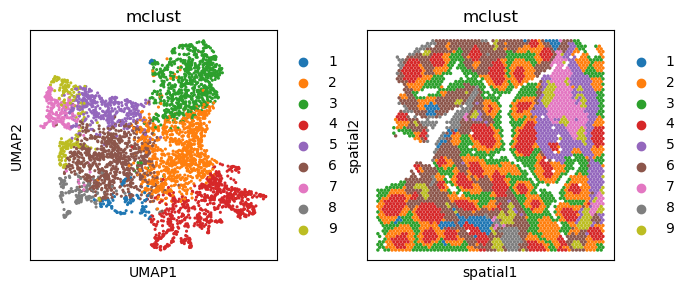

In [14]:
fig, ax_list = plt.subplots(1, 2, figsize=(7, 3))
sc.pl.umap(adata1, ax=ax_list[0],color='mclust', s=20, show=False)
sc.pl.embedding(adata, ax=ax_list[1],basis='spatial', color='mclust', s=25, show=False)
plt.tight_layout(w_pad=0.3)
plt.show()

In [7]:
import pandas as pd
adata = sc.read_h5ad("E:/Spatial_data/Data_SpatialGlue/tutorials/Human_Lymph_Node/adata_RNA.h5ad")
adata.var_names_make_unique()
# 读取 CSV 文件，假设第一列是索引或者 barcode 列
new_labels_df = pd.read_csv(r"C:\Users\huahua\Desktop\Part_Two_Multi_Omics\baseline\human lymph nodeA1\Ours\epochs_310_cluster_labels.csv",index_col=0) 
# 或者如果 barcode 是其中一列：
# new_labels_df = pd.read_csv('epochs_270_cluster_labels.csv').set_index('barcode')
# 核心代码：直接根据 barcode 映射新的 mclust 标签
adata.obs['mclust'] = adata.obs_names.map(new_labels_df['mclust'])

# 如果你的 mclust 需要是分类（category）类型，可以转换一下
adata.obs['mclust'] = adata.obs['mclust'].astype('category')
print(adata.obs['mclust'].head())

AACACTTGGCAAGGAA-1    5
AACAGGATTCATAGTT-1    5
AACAGGTTATTGCACC-1    5
AACAGGTTCACCGAAG-1    1
AACAGTCAGGCTCCGC-1    1
Name: mclust, dtype: category
Categories (6, int64): [1, 2, 3, 4, 5, 6]


In [18]:
###Moran
import numpy as np
import pandas as pd
import libpysal
from esda.moran import Moran

# 假设 adata 有聚类标签存储在 adata.obs['mclust'] 中
cluster_labels = adata.obs['mclust'].astype('category').cat.codes
# 或者，如果我们有具体的类别名称，我们可以为每个类别创建一个二值向量

# 获取类别名称
categories = adata.obs['mclust'].unique()

# 存储每个类别的 Moran's I 结果
results = []

# 构建空间权重矩阵（使用空间坐标）
coords = adata.obsm['spatial']
w = libpysal.weights.KNN(coords, k=6)

for category in categories:
    # 创建二值向量：当前类别为1，其他为0
    binary_vector = (adata.obs['mclust'] == category).astype(int).values
    
    # 计算 Moran's I
    moran = Moran(binary_vector, w)
    results.append({
        'Category': category,
        'Morans_I': moran.I,
        'P_value': moran.p_norm
    })

# 转换为 DataFrame
results_df = pd.DataFrame(results)
# ===================== 新增：计算均值和中位数 =====================
moran_values = results_df['Morans_I']
moran_mean = moran_values.mean()    # 平均数
moran_median = moran_values.median()# 中位数

# 打印结果
print("===== 每个类别的 Moran's I 结果 =====")
print(results_df)
print("\n===== 统计汇总 =====")
print(f"Moran's I 平均数: {moran_mean:.4f}")
print(f"Moran's I 中位数: {moran_median:.4f}")

# ===================== 保存到指定路径 =====================
save_path = r"C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\Moran_I.csv"
results_df.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"\n✅ 结果已保存至：\n{save_path}")

===== 每个类别的 Moran's I 结果 =====
   Category  Morans_I  P_value
0         5  0.430924      0.0
1         4  0.634424      0.0
2         3  0.584762      0.0
3         2  0.747719      0.0
4         7  0.749601      0.0
5         8  0.635679      0.0
6         1  0.540349      0.0
7         6  0.666278      0.0
8         9  0.600995      0.0

===== 统计汇总 =====
Moran's I 平均数: 0.6212
Moran's I 中位数: 0.6344

✅ 结果已保存至：
C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\Moran_I.csv


In [21]:
###绘制单个域
save_folder = r"C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium"
# 使用 range(1, 19) 会生成 1 到 18 的整数序列
for i in range(1, 10):
    # 1. 创建画布 (每次循环都要新建，避免画面重叠)
    fig, ax = plt.subplots(figsize=(2.8, 2.8))
    
    # 转为字符串，以匹配 Scanpy 默认的类别存储格式
    #target_cluster = f'{i}'
    target_cluster = i
    
    # 2. 绘制当前类的空间图
    # 这里的 groups 接收的是字符串列表，例如 ['1'], ['2'] ...
    sc.pl.embedding(
        adata1, 
        basis='spatial', 
        color='mclust', 
        groups=[target_cluster], 
        s=30, 
        ax=ax, 
        show=False
    )
    
    # 3. 动态命名并保存
    file_name = f'{target_cluster}_cluster.png'
    save_path = os.path.join(save_folder, file_name)
    
    # 加上 bbox_inches='tight' 避免切掉图例
    plt.savefig(save_path, dpi=300)
    
    # 打印进度，方便你知道代码运行到哪了
    print(f"成功保存第 {target_cluster} 类的图片至: {save_path}")
    
    # 4. 必须在当前循环结束前关闭图形，彻底释放内存
    plt.close(fig)

成功保存第 1 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\1_cluster.png
成功保存第 2 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\2_cluster.png
成功保存第 3 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\3_cluster.png
成功保存第 4 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\4_cluster.png
成功保存第 5 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\5_cluster.png
成功保存第 6 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\6_cluster.png
成功保存第 7 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\7_cluster.png
成功保存第 8 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\8_cluster.png
成功保存第 9 类的图片至: C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium\9_cluster.png


In [2]:
adata = sc.read_h5ad("E:/Spatial_data/muti_omics/miso_tutorial_data/updated_rna.h5ad")
adata.var_names_make_unique()

In [21]:
adata.obs['mclust']

AACACGTGCATCGCAC-1    2
AACACTTGGCAAGGAA-1    4
AACAGGAAGAGCATAG-1    4
AACAGGATTCATAGTT-1    3
AACAGGCCAACGATTA-1    3
                     ..
TGTTGGAACCTTCCGC-1    5
TGTTGGAACGAGGTCA-1    9
TGTTGGAAGCTCGGTA-1    8
TGTTGGATGGACTTCT-1    3
TGTTGGCCAGACCTAC-1    2
Name: mclust, Length: 4194, dtype: category
Categories (9, object): ['1', '2', '3', '4', ..., '6', '7', '8', '9']

In [3]:
#读标签
import scanpy as sc
import pandas as pd

# ===================== 固定路径 =====================
csv_path = r"C:\Users\huahua\Desktop\Part_Two_Multi_Omics\baseline\Human tonsils\Ours\epochs_100_cluster_labels.csv"

# 1. 读取标签文件（第一列是细胞ID，第二列是 mclust）
df = pd.read_csv(csv_path, index_col=0)

# 2. 按 adata 细胞顺序严格对齐（防止错位）
df = df.reindex(adata.obs_names)

# 3. 把 mclust 标签加入 adata.obs
adata.obs['mclust'] = df['mclust'].astype('category')

# ===================== 验证结果 =====================
print("✅ mclust 标签已成功添加到 adata.obs['mclust']")
print("\n前5个标签：")
print(adata.obs['mclust'].head())
print("\n标签数量统计：")
print(adata.obs['mclust'].value_counts())

✅ mclust 标签已成功添加到 adata.obs['mclust']

前5个标签：
AACACGTGCATCGCAC-1    5
AACACTTGGCAAGGAA-1    4
AACAGGAAGAGCATAG-1    4
AACAGGATTCATAGTT-1    3
AACAGGCCAACGATTA-1    3
Name: mclust, dtype: category
Categories (9, int64): [1, 2, 3, 4, ..., 6, 7, 8, 9]

标签数量统计：
5    921
3    769
4    681
6    555
2    473
8    339
7    219
9    137
1    100
Name: mclust, dtype: int64


In [8]:
# 直接转成 category + 字符串
adata.obs['mclust'] = adata.obs['mclust'].astype(str).astype('category')

In [9]:
sc.tl.rank_genes_groups(adata, groupby='mclust', method='wilcoxon')#排名靠前的基因是在组间差异更显著的基因

In [10]:
sc.tl.dendrogram(adata, groupby='mclust')

         Falling back to preprocessing with `sc.pp.pca` and default params.


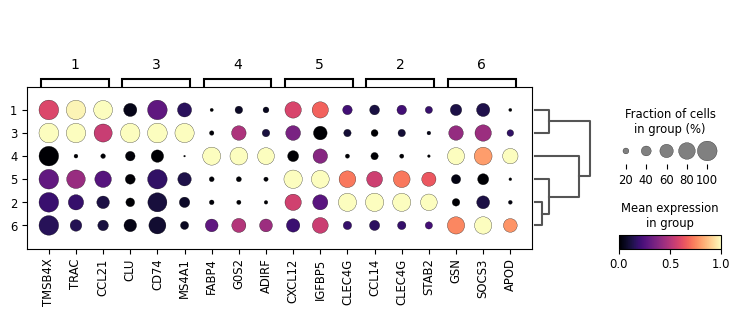

In [14]:
import os
import matplotlib.pyplot as plt
import scanpy as sc

# 确保分组列是字符串类型
adata.obs['mclust'] = adata.obs['mclust'].astype(str)

# 设置保存路径
save_folder = r"C:\Users\huahua\Desktop\Part_Two_Multi_Omics\baseline\human lymph nodeA1\Ours"
os.makedirs(save_folder, exist_ok=True)  # 确保目录存在

# 绘制点图（关键修改）
fig = sc.pl.rank_genes_groups_dotplot(
    adata, 
    n_genes=3, 
    groupby='mclust',
    standard_scale='var',
    cmap='magma',
    show=False,          # 禁止自动显示
    return_fig=True      # 返回图形对象
)

# 保存图像（解决保存不全问题）
save_path = os.path.join(save_folder, 'dif_5expre_dotp_magma.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示图像（可选）
plt.show()


In [42]:
# 提取具体的数据框
result_df = sc.get.rank_genes_groups_df(adata, group="4") # 查看第1个聚类的差异基因
result_df

,names,scores,logfoldchanges,pvals,pvals_adj
0,RGS13,40.942585,NaN,0.000000e+00,0.000000e+00
1,LRMP,40.741959,NaN,0.000000e+00,0.000000e+00
2,MEF2B,40.573387,NaN,0.000000e+00,0.000000e+00
3,HIST1H1B,40.568233,NaN,0.000000e+00,0.000000e+00
4,ELL3,40.494598,NaN,0.000000e+00,0.000000e+00
...,...,...,...,...,...
18025,AHNAK,-35.981335,NaN,1.638574e-283,2.591535e-281
18026,GPR183,-36.246346,NaN,1.134504e-287,1.948105e-285
18027,S100A6,-36.685139,NaN,1.260465e-294,2.582520e-292
18028,CD44,-38.344288,NaN,0.000000e+00,0.000000e+00


In [21]:
adata

AnnData object with n_obs × n_vars = 4194 × 18085
    obs: 'mclust'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'rank_genes_groups'
    obsm: 'spatial'

In [23]:
# 提取原始坐标
x_orig = adata.obsm['spatial'][:, 0].copy()
y_orig = adata.obsm['spatial'][:, 1].copy()

# 逆时针旋转90度：新x = -原y，新y = 原x
adata.obsm['spatial'][:, 0] = -y_orig  # 新X坐标 = -原Y
adata.obsm['spatial'][:, 1] = x_orig   # 新Y坐标 = 原X
adata.obsm['spatial'][:, 1] = -adata.obsm['spatial'][:, 1]

In [27]:
# 直接翻转 adata.obsm['spatial'] 的 Y 轴坐标
adata.obsm['spatial'][:, 0] = -adata.obsm['spatial'][:, 0]

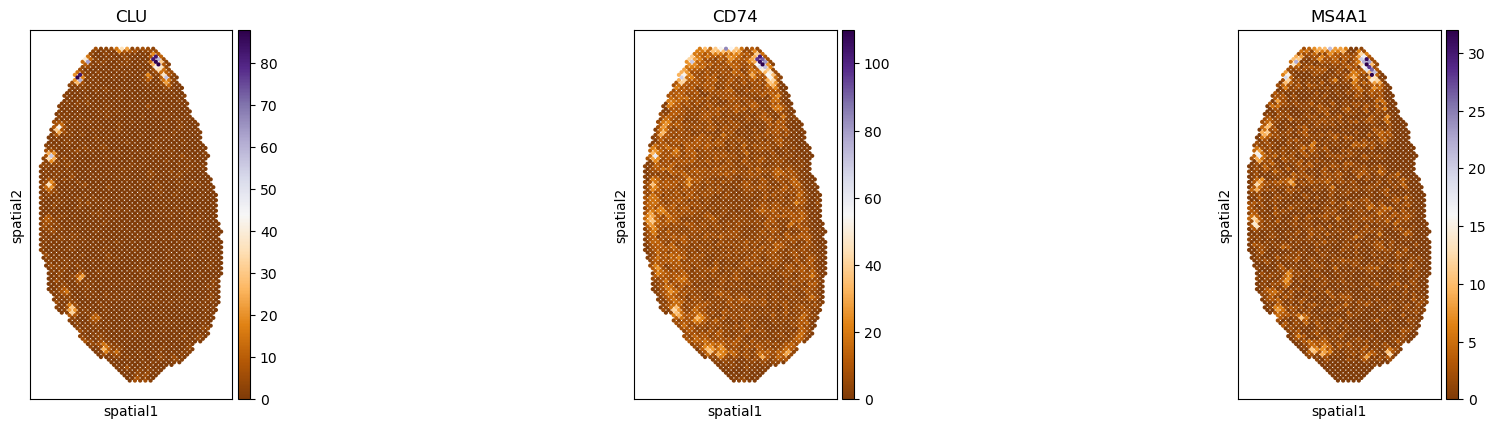

In [19]:
#fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.spatial(
    adata,          # 仅使用 cluster1 的数据
    #color=['RGS13', 'LRMP','MEF2B','HIST1H1B'],   
    color=[ 'CLU','CD74','MS4A1'],   # 要绘制的基因
    spot_size=1.6,             # 空间点大小（根据你的数据调整）
    #title=f"Cluster 1 - {gene_name} Expression",
    cmap="PuOr",          # 配色方案
    show=False,   
   # vmin=-2,
   # vmax=30
          
)
#保存
save_folder = r"C:\Users\huahua\Desktop\Part_Two_Multi_Omics\baseline\human lymph nodeA1\Ours"

save_path = os.path.join(save_folder, '3_dif_expre_magma_vmin=PuOr')
plt.savefig(save_path,dpi=300)
plt.show()
# 关闭图形以释放内存
plt.close()


Cluster 4 KEGG enrichment results:
          Gene_set                               Term Overlap   P-value  \
0  KEGG_2021_Human  Pantothenate and CoA biosynthesis    1/21  0.020801   
1  KEGG_2021_Human             FoxO signaling pathway   1/131  0.123215   
2  KEGG_2021_Human           Apelin signaling pathway   1/137  0.128497   
3  KEGG_2021_Human     Ubiquitin mediated proteolysis   1/140  0.131128   
4  KEGG_2021_Human         cGMP-PKG signaling pathway   1/167  0.154461   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.208015            0                     0   52.526316   
1          0.246367            0                     0    8.036437   
2          0.246367            0                     0    7.679567   
3          0.246367            0                     0    7.512685   
4          0.246367            0                     0    6.282181   

   Combined Score   Genes  
0      203.420329    VNN2  
1       16.826905    BCL6  
2       1

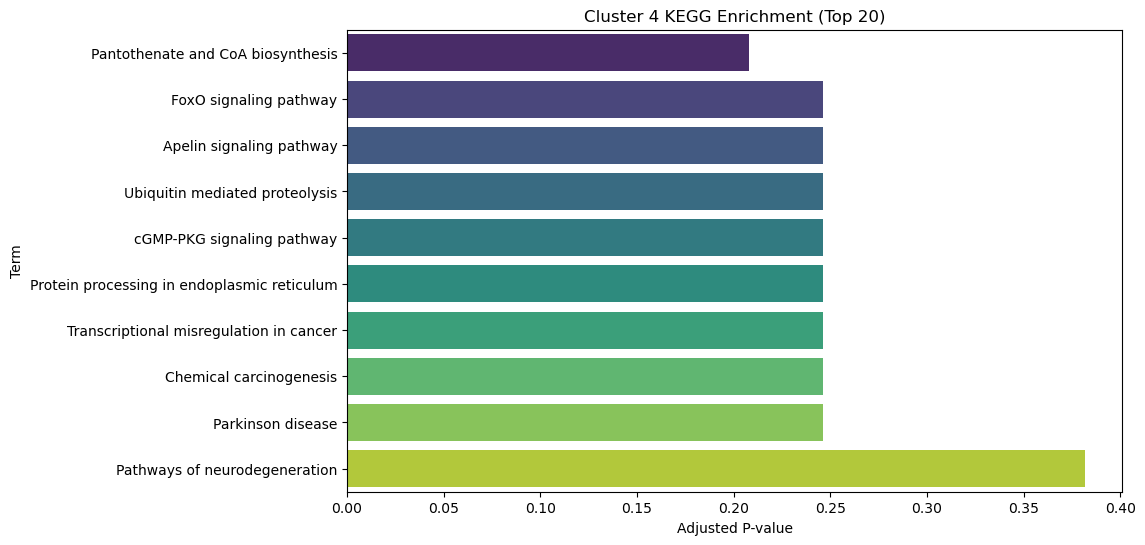

In [28]:
import gseapy as gp
import seaborn as sns
cluster_4_genes = pd.DataFrame(adata.uns['rank_genes_groups']['names'])['4']
# 提取前 10 个基因
top_20_genes = cluster_4_genes.head(20).tolist()


enr_1 = gp.enrichr(gene_list=top_20_genes,
                        gene_sets=['KEGG_2021_Human'],
                        organism='Human',
                        outdir=None)

# 查看第 1 类的富集结果
print("Cluster 4 KEGG enrichment results:")
print(enr_1.results.head())

# 绘制第 1 类的富集结果条形图
plt.figure(figsize=(10, 6))
sns.barplot(x='Adjusted P-value', y='Term', data=enr_1.results.head(10),palette='viridis')
plt.title('Cluster 4 KEGG Enrichment (Top 20)')

save_folder = r"C:\Users\huahua\Desktop\Part_Two_Multi_Omics\test\human tonsil 10x Visium"

save_path = os.path.join(save_folder, '4_Go_viridis')
plt.savefig(save_path,dpi=300,bbox_inches='tight')
plt.show()
# 关闭图形以释放内存
plt.close()

In [ ]:
##循环

In [ ]:

STAGATE_pyG.Cal_Gene_Similarity_Net_KNN(adata1, k_neighbors=6, metric='cosine', verbose=True)
STAGATE_pyG.Cal_Gene_Similarity_Net_Kmeans(adata1, n_clusters=6, connect_type='intra_cluster_all',metric='cosine')
STAGATE_pyG.get_intersection_KNN_KMeans(adata1)

STAGATE_pyG.Cal_Gene_Similarity_Net_KNN(adata2, k_neighbors=6, metric='cosine', verbose=True)
STAGATE_pyG.Cal_Gene_Similarity_Net_Kmeans(adata2, n_clusters=6, connect_type='intra_cluster_all',metric='cosine')
STAGATE_pyG.get_intersection_KNN_KMeans(adata2)
STAGATE_pyG.merge_local_global_net(adata1, net_key1='Spatial_Net_local', net_key2='Gene_Similarity_Net_Intersection')
STAGATE_pyG.merge_local_global_net(adata2, net_key1='Spatial_Net_local', net_key2='Gene_Similarity_Net_Intersection')

In [32]:
# 定义迭代次数列表
epoch_list = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
               210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,500,600,700,800,900,1000]
#epoch_list = [1,2]  # 测试用的小列表

# 定义参数
knn_value = 6  # k近邻参数
kmeans_iter = 6  # k-means迭代次数
num_cluster = 9  # 聚类数量

# 存储详细Moran指数结果的列表
all_moran_results = []  # 存储所有Moran指数详细结果

# 结果保存路径
result_dir = r"E:\论文\Part_Two_Multi_Omics\test\human tonsil 10x Visium\knn6_kmeans6\cluster_9"
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
#变换坐标
# 提取原始坐标
# x_orig = adata.obsm['spatial'][:, 0].copy()
# y_orig = adata.obsm['spatial'][:, 1].copy()
# # 逆时针旋转90度：新x = -原y，新y = 原x
# adata.obsm['spatial'][:, 0] = -y_orig  # 新X坐标 = -原Y
# adata.obsm['spatial'][:, 1] = x_orig   # 新Y坐标 = 原X
# adata.obsm['spatial'][:, 1] = -adata.obsm['spatial'][:, 1]

# 循环不同迭代次数
for n_epochs in epoch_list:
    print(f"\n{'='*50}")
    print(f"Training with {n_epochs} epochs...")
    
    # 复制原始数据（避免修改原始数据）
    adata1_copy = adata1.copy()
    adata2_copy = adata2.copy()
    
    # 训练模型
    adata1_copy, adata2_copy = STAGATE_pyG.train_STAGATE(adata1_copy, adata2_copy, n_epochs=n_epochs)
    
    # 聚类
    adata_clustered = STAGATE_pyG.mclust_R(adata1_copy, used_obsm='STAGATE', num_cluster=9)
    
    # 保存聚类标签
    cluster_labels = adata_clustered.obs[['mclust']].copy()
    labels_path = os.path.join(result_dir, f'epochs_{n_epochs}_cluster_labels.csv')
    cluster_labels.to_csv(labels_path)
    print(f"Saved cluster labels to: {labels_path}")
    
    # 计算邻居和UMAP
    sc.pp.neighbors(adata_clustered, use_rep='STAGATE', n_neighbors=10)
    sc.tl.umap(adata_clustered)
    
    # ====== 计算Moran指数 ======
    # 获取类别名称
    categories = adata_clustered.obs['mclust'].unique()
    
    # 存储每个类别的Moran's I结果
    moran_results = []
    
    # 构建空间权重矩阵（使用空间坐标）
    coords = adata_clustered.obsm['spatial']
    w = libpysal.weights.KNN(coords, k=6)
    
    for category in categories:
        # 创建二值向量：当前类别为1，其他为0
        binary_vector = (adata_clustered.obs['mclust'] == category).astype(int).values
        
        # 计算Moran's I
        moran = Moran(binary_vector, w)
        moran_results.append({
            'Epochs': n_epochs,  # 添加迭代次数
            'Category': category,
            'Morans_I': moran.I,
            'P_value': moran.p_norm
        })
    
    # 转换为DataFrame
    moran_df = pd.DataFrame(moran_results)
    
    # 计算Moran指数的中位数
    median_moran = moran_df['Morans_I'].median()
    
    # 收集详细Moran结果
    all_moran_results.append(moran_df)
    
    print(f"Median Moran's I: {median_moran:.4f}")
    print(moran_df)
    
    # ====== 可视化聚类结果 ======
    fig, ax_list = plt.subplots(1, 2, figsize=(7, 3.5))
    sc.pl.umap(adata_clustered, ax=ax_list[0], color='mclust', s=22, show=False)
    sc.pl.embedding(adata_clustered, ax=ax_list[1], basis='spatial', color='mclust', s=22, show=False)
    
    # 添加标题 - 包含中位数Moran指数
    title = (f'Training Epochs: {n_epochs}, '
             f'knn={knn_value}, kmeans={kmeans_iter}, '
             f'clusters={num_cluster}\n'
             f'Median Moran\'s I: {median_moran:.4f}')
    fig.suptitle(title, fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # 为标题留出空间
    
    # 保存可视化结果
    fig_path = os.path.join(result_dir, f'epochs_{n_epochs}_clusters.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved visualization to: {fig_path}")

# 保存所有详细Moran结果到CSV
all_moran_df = pd.concat(all_moran_results, ignore_index=True)
detailed_path = os.path.join(result_dir, 'Moran_results.csv')
all_moran_df.to_csv(detailed_path, index=False)
print(f"\n{'='*50}")
print(f"Saved detailed Moran results to: {detailed_path}")
print(all_moran_df)


Training with 10 epochs...
Size of Input:  (4194, 3000)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:11<00:00,  1.17s/it]


fitting ...
  |======================================================================| 100%
Saved cluster labels to: E:\论文\Part_Two_Multi_Omics\test\human tonsil 10x Visium\knn6_kmeans6\cluster_9\epochs_10_cluster_labels.csv
Median Moran's I: 0.6047
   Epochs  Category  Morans_I        P_value
0      10         9  0.205369  2.859801e-126
1      10         4  0.613892   0.000000e+00
2      10         6  0.512444   0.000000e+00
3      10         7  0.652567   0.000000e+00
4      10         5  0.790168   0.000000e+00
5      10         2  0.414204   0.000000e+00
6      10         3  0.335326   0.000000e+00
7      10         1  0.604742   0.000000e+00
8      10         8  0.614104   0.000000e+00
Saved visualization to: E:\论文\Part_Two_Multi_Omics\test\human tonsil 10x Visium\knn6_kmeans6\cluster_9\epochs_10_clusters.png

Training with 20 epochs...
Size of Input:  (4194, 3000)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:22<00:00,  1.14s/it]


fitting ...
  |======================================================================| 100%
Saved cluster labels to: E:\论文\Part_Two_Multi_Omics\test\human tonsil 10x Visium\knn6_kmeans6\cluster_9\epochs_20_cluster_labels.csv
Median Moran's I: 0.5308
   Epochs  Category  Morans_I        P_value
0      20         9  0.247004  1.102797e-181
1      20         4  0.622705   0.000000e+00
2      20         6  0.496997   0.000000e+00
3      20         8  0.530793   0.000000e+00
4      20         5  0.808718   0.000000e+00
5      20         2  0.408800   0.000000e+00
6      20         3  0.353417   0.000000e+00
7      20         7  0.601344   0.000000e+00
8      20         1  0.634679   0.000000e+00
Saved visualization to: E:\论文\Part_Two_Multi_Omics\test\human tonsil 10x Visium\knn6_kmeans6\cluster_9\epochs_20_clusters.png

Training with 30 epochs...
Size of Input:  (4194, 3000)


...

 90%|████████████████████████████████████████████████████████████████████████████████████████████████████▊           | 900/1000 [16:52<01:53,  1.14s/it]

Epoch 900:
  Reconstruction Loss: 0.7180
  Contrastive Loss: 0.0000
  Total Loss: 0.7180
  Fusion Weight Mean: 0.8130


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [18:44<00:00,  1.12s/it]

Epoch 1000:
  Reconstruction Loss: 0.7123
  Contrastive Loss: 0.0000
  Total Loss: 0.7123
  Fusion Weight Mean: 0.8297


fitting ...
  |======================================================================| 100%
Saved cluster labels to: E:\论文\Part_Two_Multi_Omics\test\human tonsil 10x Visium\knn6_kmeans6\cluster_9\epochs_1000_cluster_labels.csv
Median Moran's I: 0.4857
   Epochs  Category  Morans_I  P_value
0    1000         4  0.625740      0.0
1    1000         5  0.391650      0.0
2    1000         3  0.405170      0.0
3    1000         8  0.486124      0.0
4    1000         7  0.702363      0.0
5    1000         2  0.397554      0.0
6    1000         6  0.566513      0.0
7    1000         9  0.485695      0.0
8    1000         1  0.402760      0.0
Saved visualization to: E:\论文\Part_Two_Multi_Omics\test\human tonsil 10x Visium\knn6_kmeans6\cluster_9\epochs_1000_clusters.png

Saved detailed Moran results to: E:\论文\Part_Two_Multi_Omics\test\human tonsil 10x Visium\knn6_kmeans6\cluster_9\Moran_results.csv
     Epochs  Category  Morans_I        P_value
0        10         9  0.205369  2.859801e-126
1    